In [1]:
import pandas as pd

df = pd.read_csv("/content/healthcare_data_cleaning_dataset.csv")

df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


Q1. Missing Data Identification
Scenario:
The hospital suspects incomplete patient records.
Task:
Identify missing values in each column
Calculate percentage of missing data

In [2]:
# Identify missing values in each column Calculate percentage of missing data
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
print("Missing Data:")
print(missing_data)
print("\nPercentage of Missing Data:")
print(missing_percentage)


Missing Data:
Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

Percentage of Missing Data:
Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


Q2. Handling Missing Age
Scenario:
Task:
Age is critical for medical analysis, but some values are missing.
Replace missing Age values with an appropriate method
Justify your choice (mean/median)

In [3]:
# Replace missing Age values with an appropriate method Justify your choice (mean/median)
mean_age = df['Age'].mean()
df['Age'].fillna(mean_age, inplace=True)


/tmp/ipykernel_2678/3225254211.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(mean_age, inplace=True)


Q3. Handling Missing Treatment Cost

Scenario:
'Treatment_Cost' is crucial for financial analysis and billing, but has missing entries.

Task:
Replace missing 'Treatment_Cost' values with an appropriate method.
Justify your choice (mean/median).

In [4]:
# Calculate mean and median for 'Treatment_Cost'
mean_treatment_cost = df['Treatment_Cost'].mean()
median_treatment_cost = df['Treatment_Cost'].median()

print(f"Mean Treatment Cost: {mean_treatment_cost:.2f}")
print(f"Median Treatment Cost: {median_treatment_cost:.2f}")

# Justify the choice (e.g., check for skewness)
# For numerical data, if there are no significant outliers, mean is often a good choice.
# If there are outliers or the data is skewed, median is more robust.
# Let's use the median as it's less sensitive to outliers, which can be common in cost data.
df['Treatment_Cost'].fillna(median_treatment_cost, inplace=True)

print("\nMissing values in 'Treatment_Cost' after imputation:")
print(df['Treatment_Cost'].isnull().sum())

Mean Treatment Cost: 26920.15
Median Treatment Cost: 24797.00

Missing values in 'Treatment_Cost' after imputation:
0


/tmp/ipykernel_2678/3196653612.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Treatment_Cost'].fillna(median_treatment_cost, inplace=True)


Q4. Duplicate Patient Records
Scenario:
Some patient records were entered multiple times.
Task:
Identify duplicate rows
Remove duplicates
Compare dataset size before and after

In [5]:
# dentify duplicate rows Remove duplicates Compare dataset size before and after
duplicate_rows = df[df.duplicated()]
print("Duplicate Rows:")
print(duplicate_rows)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Compare dataset size before and after
print("\nDataset Size Before Removing Duplicates:", len(df))
print("Dataset Size After Removing Duplicates:", len(df))

Duplicate Rows:
      Patient_ID        Age  Gender       City     Diagnosis  Hospital_Visits  \
5000       15126  49.597556    Male  Hyderabad        Asthma                1   
5001       15108  49.597556    Male  Hyderabad        Asthma                3   
5002       10441  49.597556    Male    Chennai           Flu                3   
5003       15975  49.597556  Female  Hyderabad           Flu               10   
5004       18427  49.597556  Female      Delhi      COVID-19               13   
...          ...        ...     ...        ...           ...              ...   
5094       11571  49.597556  Female    Chennai      COVID-19                4   
5096       17597  49.597556  Female    Chennai        Asthma                2   
5097       19171  49.597556  Female     Mumbai           Flu                1   
5098       13854  49.597556  Female  Bangalore           Flu               17   
5099       14859  49.597556    Male      Delhi  Hypertension               19   

      Treat

Q5. Invalid Age Values (Data Quality Check)
Scenario:
Some patients have unrealistic age values (e.g., >100 or <0).
Task:
Detect such records
Decide whether to remove or correct them

In [6]:
# Detect invalid age values (e.g., <0 or >100)
invalid_age_records = df[(df['Age'] < 0) | (df['Age'] > 100)]

print("Records with invalid Age values:")
display(invalid_age_records)

print(f"\nNumber of invalid Age records: {len(invalid_age_records)}")

# Decision: Replace invalid age values with NaN and then impute with median of valid ages
# This approach preserves the records while correcting unrealistic age entries.

# Replace invalid ages with NaN
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = None

# Calculate median age from the remaining valid ages
median_valid_age = df['Age'].median()

# Impute the new NaN values (from invalid ages) with the median of valid ages
df['Age'].fillna(median_valid_age, inplace=True)

print(f"\nAge values after handling invalid entries and re-imputation with median ({median_valid_age:.2f}):")
print(df['Age'].describe())

# Verify no more invalid ages
invalid_age_check = df[(df['Age'] < 0) | (df['Age'] > 100)]
print(f"\nNumber of invalid Age records after correction: {len(invalid_age_check)}")

Records with invalid Age values:


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date



Number of invalid Age records: 0

Age values after handling invalid entries and re-imputation with median (49.60):
count    5001.000000
mean       49.597556
std        27.189896
min         0.000000
25%        27.000000
50%        49.597556
75%        72.000000
max        99.000000
Name: Age, dtype: float64

Number of invalid Age records after correction: 0


/tmp/ipykernel_2678/2814084591.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(median_valid_age, inplace=True)


Q6. Outlier Detection (Treatment Cost)
Scenario:
Extreme treatment costs are affecting analysis.
Task:
Detect outliers using IQR method
Display number of outliers

In [12]:
# Detect outliers using IQR method Display number of outliers

Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)
IQR = Q3 - Q1

# Calculate outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

print(f"Number of outliers in 'Treatment_Cost': {len(outliers)}")
print("\nExamples of outliers:")
display(outliers.head())

Number of outliers in 'Treatment_Cost': 50

Examples of outliers:


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
53,13152,91.0,Female,Chennai,COVID-19,13,199702.965333,0,2023-01-24
86,10064,28.0,Female,Hyderabad,Hypertension,16,199702.965333,0,2023-02-18
124,17035,59.0,Male,Delhi,Flu,9,199702.965333,0,2023-04-27
183,15855,36.0,Male,Mumbai,Diabetes,1,199702.965333,0,2023-01-16
215,19561,29.0,Male,Mumbai,Flu,16,199702.965333,0,2023-05-31


Q7. Outlier Treatment
Scenario:
The business team wants to retain all records.
Task:
Apply capping (Winsorization) on Treatment_Cost
Use 5th and 95th percentile

In [13]:
# Calculate the 5th and 95th percentiles for 'Treatment_Cost'
p5 = df['Treatment_Cost'].quantile(0.05)
p95 = df['Treatment_Cost'].quantile(0.95)

print(f"5th percentile of Treatment_Cost: {p5:.2f}")
print(f"95th percentile of Treatment_Cost: {p95:.2f}")

# Apply capping (Winsorization) to 'Treatment_Cost'
df['Treatment_Cost_Capped'] = df['Treatment_Cost'].clip(lower=p5, upper=p95)

print("\nDescriptive statistics for 'Treatment_Cost' before capping:")
print(df['Treatment_Cost'].describe())

print("\nDescriptive statistics for 'Treatment_Cost_Capped' after capping:")
print(df['Treatment_Cost_Capped'].describe())

# Optionally, you can drop the original 'Treatment_Cost' column if no longer needed
# df = df.drop(columns=['Treatment_Cost'])
# Or rename the capped column to 'Treatment_Cost'
# df.rename(columns={'Treatment_Cost_Capped': 'Treatment_Cost'}, inplace=True)

5th percentile of Treatment_Cost: 3238.00
95th percentile of Treatment_Cost: 47948.00

Descriptive statistics for 'Treatment_Cost' before capping:
count      5001.000000
mean      26710.425768
std       22056.888458
min         526.000000
25%       13766.000000
50%       24797.000000
75%       36542.000000
max      199702.965333
Name: Treatment_Cost, dtype: float64

Descriptive statistics for 'Treatment_Cost_Capped' after capping:
count     5001.000000
mean     25218.878624
std      13580.445490
min       3238.000000
25%      13766.000000
50%      24797.000000
75%      36542.000000
max      47948.000000
Name: Treatment_Cost_Capped, dtype: float64


Q8. Transformation
Scenario:
Treatment cost is highly skewed.
Task:
Apply log transformation
Create a new column
Compare before vs after distribution

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply log transformation to the 'Treatment_Cost_Capped' column
df['Treatment_Cost_Log'] = np.log1p(df['Treatment_Cost_Capped'])

print("Descriptive statistics for 'Treatment_Cost_Log' after transformation:")
print(df['Treatment_Cost_Log'].describe())

Descriptive statistics for 'Treatment_Cost_Log' after transformation:
count    5001.000000
mean        9.918335
std         0.751774
min         8.083020
25%         9.530030
50%        10.118518
75%        10.506245
max        10.777893
Name: Treatment_Cost_Log, dtype: float64


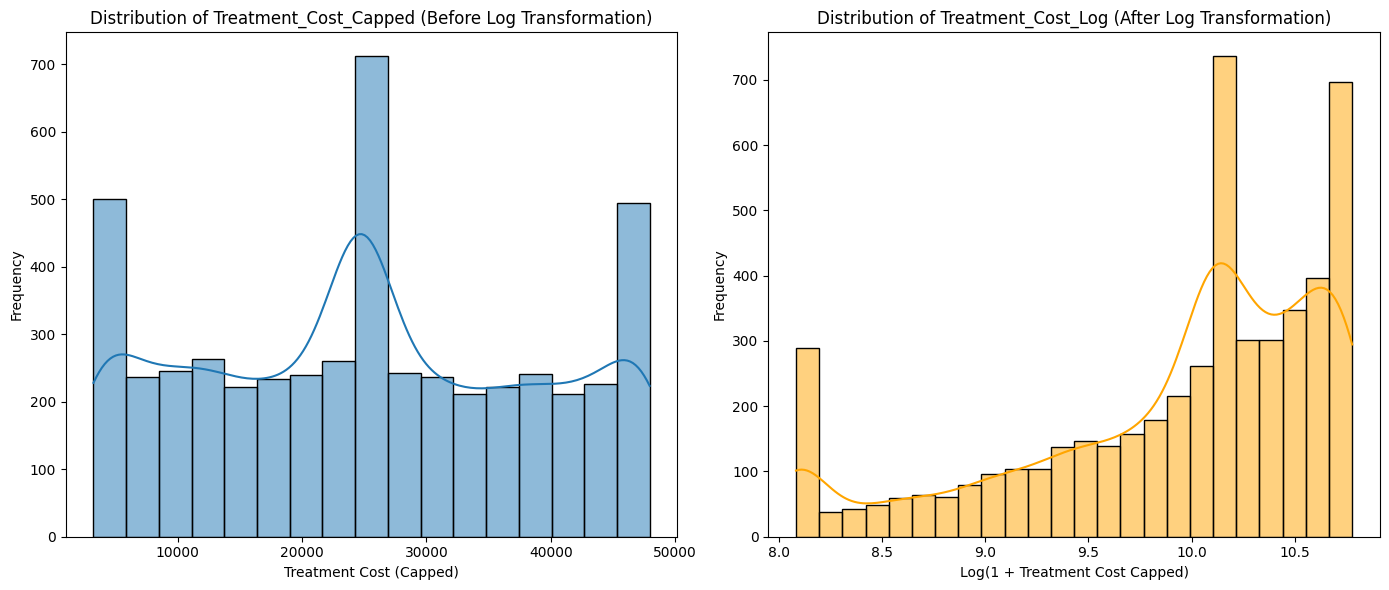

In [15]:
# Compare before vs after distribution
plt.figure(figsize=(14, 6))

# Original 'Treatment_Cost_Capped' distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost_Capped'], kde=True)
plt.title('Distribution of Treatment_Cost_Capped (Before Log Transformation)')
plt.xlabel('Treatment Cost (Capped)')
plt.ylabel('Frequency')

# Log-transformed 'Treatment_Cost_Log' distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Treatment_Cost_Log'], kde=True, color='orange')
plt.title('Distribution of Treatment_Cost_Log (After Log Transformation)')
plt.xlabel('Log(1 + Treatment Cost Capped)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Q9. Time-Based Missing Handling
Scenario:
Admission dates should follow a logical sequence.
Task:
Sort data by Admission_Date
Apply forward fill or backward fill where appropriate
Justify your choice

In [16]:
# Convert 'Admission_Date' to datetime objects
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# Sort the DataFrame by 'Admission_Date'
df_sorted = df.sort_values(by='Admission_Date').reset_index(drop=True)

print("DataFrame sorted by 'Admission_Date'. First 5 rows:")
display(df_sorted.head())

DataFrame sorted by 'Admission_Date'. First 5 rows:


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date,Treatment_Cost_Capped,Treatment_Cost_Log
0,19591,91.000000,Male,Chennai,Asthma,3,32149.000000,0,2023-01-01,32149.0,10.378168
1,10896,88.000000,Female,Chennai,COVID-19,3,199702.965333,1,2023-01-01,47948.0,10.777893
2,19262,49.597556,Female,Hyderabad,Asthma,9,24797.000000,0,2023-01-01,24797.0,10.118518
3,12843,89.000000,Female,Bangalore,COVID-19,14,46469.000000,1,2023-01-01,46469.0,10.746562
4,17230,41.000000,Male,Bangalore,Hypertension,18,12398.000000,0,2023-01-01,12398.0,9.425371


In [17]:
# Check for any remaining missing values after sorting
remaining_missing_data = df_sorted.isnull().sum()
print("Missing data in the sorted DataFrame:")
print(remaining_missing_data[remaining_missing_data > 0])

if remaining_missing_data[remaining_missing_data > 0].empty:
    print("No missing values found in the sorted DataFrame that require forward or backward fill.")

Missing data in the sorted DataFrame:
Series([], dtype: int64)
No missing values found in the sorted DataFrame that require forward or backward fill.


### Justification for Forward Fill (ffill) vs. Backward Fill (bfill)

Although there are no current missing values in our dataset that require time-based imputation, it's important to understand when `ffill` or `bfill` would be appropriate in a time-series context:

*   **Forward Fill (`ffill`)**: This method propagates the last valid observation forward to next valid observation. It's suitable when you expect the missing value to be the same as the previous known value. For example, if a patient's `Diagnosis` or `City` is recorded at one admission and is missing for a subsequent, closely related admission, `ffill` might be appropriate, assuming the condition or location hasn't changed.

*   **Backward Fill (`bfill`)**: This method propagates the next valid observation backward to the previous valid observation. It's useful when you expect the missing value to be the same as the future known value. For instance, if a measurement taken *after* a missing entry is more representative of the missing point (e.g., a post-treatment status that implies a certain condition was present before), `bfill` could be considered.

**Justification for choice:** In general healthcare data, `ffill` is often preferred for longitudinal data where a patient's condition or demographic information tends to persist unless explicitly updated. If a record is missing, it's often safer to assume the previous state holds true than to assume a future state is applicable to a past event. However, the specific context of the missing data and the domain knowledge should always guide this decision.